In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
def lhs(n_samples, n_dim):
    result = np.zeros((n_samples, n_dim))

    for i in range(n_dim):
        perm = np.random.permutation(n_samples)
        result[:, i] = (perm + np.random.rand(n_samples)) / n_samples

    return result

In [3]:
def f_func(x, y, t, z):
    return np.exp(-0.5*x) + np.log(1 + np.exp(0.4*y)) + np.tanh(t) + np.sin(z) - 0.4

In [4]:
def generate_data(n_samples, upper):
    X = lhs(n_samples, 4) * upper

    x, y, t, z = X[:,0], X[:,1], X[:,2], X[:,3]
    y_val = f_func(x, y, t, z)

    return X, y_val.reshape(-1,1)

In [5]:
# Train: [0,4]
X_train, y_train = generate_data(500, 4)

# Test: [0,6]
X_test, y_test = generate_data(5000, 6)

In [6]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

In [7]:
def sigma_mc(x):  # convex + monotonic
    return torch.log(1 + torch.exp(x))

def sigma_m(x):   # monotonic
    return torch.sigmoid(x)

def sigma_a(x):   # arbitrary
    return torch.sigmoid(x)

In [8]:
class ISNN1(nn.Module):
    def __init__(self, hidden=10):
        super().__init__()

        self.y_layer = nn.Linear(1, hidden)
        self.z_layer = nn.Linear(1, hidden)
        self.t_layer = nn.Linear(1, hidden)

        self.x_layer1 = nn.Linear(1 + 3*hidden, hidden)
        self.x_layer2 = nn.Linear(hidden, 1)

    def forward(self, X):
        x0 = X[:,0:1]
        y0 = X[:,1:2]
        t0 = X[:,2:3]
        z0 = X[:,3:4]

        y = sigma_mc(self.y_layer(y0))
        z = sigma_a(self.z_layer(z0))
        t = sigma_m(self.t_layer(t0))

        concat = torch.cat([x0, y, z, t], dim=1)

        x = sigma_mc(self.x_layer1(concat))
        out = self.x_layer2(x)

        return out

In [9]:
class ISNN2(nn.Module):
    def __init__(self, hidden=15):
        super().__init__()

        self.y_layer = nn.Linear(1, hidden)
        self.z_layer = nn.Linear(1, hidden)
        self.t_layer = nn.Linear(1, hidden)

        self.x_layer1 = nn.Linear(4, hidden)
        self.x_layer2 = nn.Linear(hidden + 3*hidden + 1, 1)

    def forward(self, X):
        x0 = X[:,0:1]
        y0 = X[:,1:2]
        t0 = X[:,2:3]
        z0 = X[:,3:4]

        y = sigma_mc(self.y_layer(y0))
        z = sigma_a(self.z_layer(z0))
        t = sigma_m(self.t_layer(t0))

        x1 = sigma_mc(self.x_layer1(X))

        concat = torch.cat([x1, x0, y, z, t], dim=1)
        out = self.x_layer2(concat)

        return out

In [10]:
def train_model(model, epochs=200):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        pred = model(X_train_t)
        loss = loss_fn(pred, y_train_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_pred = model(X_test_t)
            test_loss = loss_fn(test_pred, y_test_t)

        train_losses.append(loss.item())
        test_losses.append(test_loss.item())

    return train_losses, test_losses

In [11]:
model1 = ISNN1()
model2 = ISNN2()

loss1_train, loss1_test = train_model(model1)
loss2_train, loss2_test = train_model(model2)

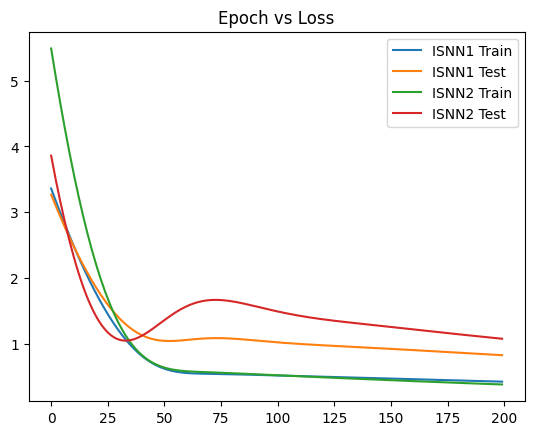

In [12]:
plt.plot(loss1_train, label="ISNN1 Train")
plt.plot(loss1_test, label="ISNN1 Test")
plt.plot(loss2_train, label="ISNN2 Train")
plt.plot(loss2_test, label="ISNN2 Test")

plt.legend()
plt.title("Epoch vs Loss")
plt.show()

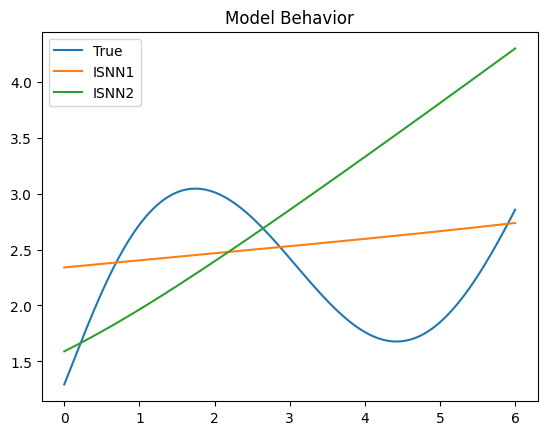

In [13]:
x = np.linspace(0,6,200)
X_plot = np.stack([x,x,x,x], axis=1)
X_plot_t = torch.tensor(X_plot, dtype=torch.float32)

with torch.no_grad():
    y_pred1 = model1(X_plot_t).numpy()
    y_pred2 = model2(X_plot_t).numpy()
    y_true = f_func(x,x,x,x)

plt.plot(x, y_true, label="True")
plt.plot(x, y_pred1, label="ISNN1")
plt.plot(x, y_pred2, label="ISNN2")

plt.legend()
plt.title("Model Behavior")
plt.show()

In [14]:
class ManualNN:
    def __init__(self):
        self.W = np.random.randn(4,1)
        self.b = np.zeros((1,))

    def forward(self, X):
        self.X = X
        self.out = np.dot(X, self.W) + self.b
        return self.out

    def loss(self, y_pred, y):
        return np.mean((y_pred - y)**2)

    def backward(self, y_pred, y, lr=0.001):
        m = len(y)

        dL = 2*(y_pred - y)/m
        dW = np.dot(self.X.T, dL)
        db = np.sum(dL)

        self.W -= lr * dW
        self.b -= lr * db

In [15]:
manual = ManualNN()

manual_losses = []

for epoch in range(200):
    pred = manual.forward(X_train)
    loss = manual.loss(pred, y_train)

    manual.backward(pred, y_train)

    manual_losses.append(loss)

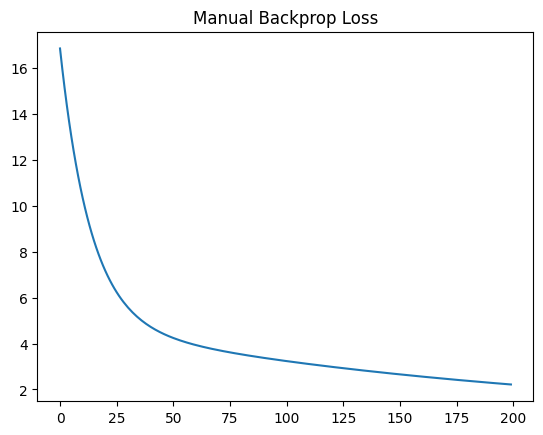

In [16]:
plt.plot(manual_losses)
plt.title("Manual Backprop Loss")
plt.show()

In [20]:
# Final losses
print("ISNN-1 Final Train Loss:", loss1_train[-1])
print("ISNN-1 Final Test Loss:", loss1_test[-1])

print("ISNN-2 Final Train Loss:", loss2_train[-1])
print("ISNN-2 Final Test Loss:", loss2_test[-1])

ISNN-1 Final Train Loss: 0.4232666492462158
ISNN-1 Final Test Loss: 0.8258622288703918
ISNN-2 Final Train Loss: 0.3805385231971741
ISNN-2 Final Test Loss: 1.0763111114501953


In [21]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["ISNN-1", "ISNN-2"],
    "Train Loss": [loss1_train[-1], loss2_train[-1]],
    "Test Loss": [loss1_test[-1], loss2_test[-1]]
})

print(results)

    Model  Train Loss  Test Loss
0  ISNN-1    0.423267   0.825862
1  ISNN-2    0.380539   1.076311
